# Week 4 — Logistic Regression and Feature Scaling

**Integrated Capstone Project: Breast Cancer (two datasets)**  
**Student:** Sara Maknojia

### Notebook purpose
This notebook applies the Week 4 concepts — **logistic regression and feature scaling** — to the two breast cancer datasets I use throughout my capstone:

1. **Breast Cancer Wisconsin (Diagnostic)** — tumor morphology measurements from images (radius, texture, perimeter, area, smoothness, concavity).
2. **Breast Cancer Coimbra** — clinical, anthropometric, and blood-based biomarkers (age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, MCP-1).

This week is different from Weeks 1–3: both outcomes are binary, so logistic regression is a more appropriate model than the linear probability models I used earlier. In each part I compare logistic regression with and without feature scaling (StandardScaler and MinMaxScaler), tune the model, and look at classification metrics that matter for a healthcare problem. I do not merge the datasets, because they contain different patients and different variables; I analyze each separately and compare at the end.

### Project question
> To what extent can measurable patient and tumor characteristics help distinguish breast cancer cases from non-cancer cases?

### Targets
- Wisconsin: `1 = malignant`, `0 = benign`
- Coimbra: `1 = breast cancer patient`, `0 = healthy control`

In both, a higher predicted probability means the model leans toward cancer being present.

### Roadmap
- **Part 1** — Breast Cancer Wisconsin analysis
- **Part 2** — Breast Cancer Coimbra analysis
- **Part 3** — Comparison and overall Week 4 conclusions
- **References**

In [1]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Dataset
from sklearn.datasets import load_breast_cancer

# Model preparation
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler

# Model
from sklearn.linear_model import LogisticRegression

# Metrics
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)

# Display settings
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 120)


## Part 1 — Breast Cancer Wisconsin (Diagnostic)

This dataset is loaded from `sklearn.datasets.load_breast_cancer`. It contains 30 tumor measurements computed from digitized images, with each tumor labeled benign or malignant. The libraries imported above cover loading, scaling, logistic regression, tuning, and classification metrics.

### 1.1 Load and prepare the data

The sklearn dataset originally codes the target as:

- `0 = malignant`
- `1 = benign`

For this notebook, I switch it so that:

- `diagnosis_malignant = 1` means malignant
- `diagnosis_malignant = 0` means benign

I like this setup better because the model's predicted probability is easier to read. A higher probability means a higher predicted chance of malignancy.

In [2]:
# Load dataset
cancer = load_breast_cancer()

# Create dataframe
df = pd.DataFrame(cancer.data, columns=cancer.feature_names)

# Clean column names so they are easier to type
df.columns = df.columns.str.replace(" ", "_")

# Create binary target: 1 = malignant, 0 = benign
df["diagnosis_malignant"] = (cancer.target == 0).astype(int)
df["diagnosis_label"] = np.where(df["diagnosis_malignant"] == 1, "Malignant", "Benign")

print("Dataset shape:", df.shape)
print("Diagnosis counts:")
print(df["diagnosis_label"].value_counts())

print("Diagnosis percentages:")
print(df["diagnosis_label"].value_counts(normalize=True).round(3))

df.head()


Dataset shape: (569, 32)
Diagnosis counts:
diagnosis_label
Benign       357
Malignant    212
Name: count, dtype: int64
Diagnosis percentages:
diagnosis_label
Benign       0.627
Malignant    0.373
Name: proportion, dtype: float64


,mean_radius,mean_texture,mean_perimeter,mean_area,mean_smoothness,mean_compactness,mean_concavity,mean_concave_points,mean_symmetry,mean_fractal_dimension,radius_error,texture_error,perimeter_error,area_error,smoothness_error,compactness_error,concavity_error,concave_points_error,symmetry_error,fractal_dimension_error,worst_radius,worst_texture,worst_perimeter,worst_area,worst_smoothness,worst_compactness,worst_concavity,worst_concave_points,worst_symmetry,worst_fractal_dimension,diagnosis_malignant,diagnosis_label
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,1.0950,0.9053,8.589,153.40,0.006399,0.04904,0.05373,0.01587,0.03003,0.006193,25.38,17.33,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,1,Malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,0.5435,0.7339,3.398,74.08,0.005225,0.01308,0.01860,0.01340,0.01389,0.003532,24.99,23.41,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,1,Malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,0.7456,0.7869,4.585,94.03,0.006150,0.04006,0.03832,0.02058,0.02250,0.004571,23.57,25.53,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,1,Malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,0.4956,1.1560,3.445,27.23,0.009110,0.07458,0.05661,0.01867,0.05963,0.009208,14.91,26.50,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,1,Malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,0.7572,0.7813,5.438,94.44,0.011490,0.02461,0.05688,0.01885,0.01756,0.005115,22.54,16.67,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,1,Malignant


### 1.2 Features and target

The dataset has 30 tumor measurement features. These include measurements like radius, texture, perimeter, area, smoothness, compactness, concavity, and symmetry.

The target is whether the tumor is malignant.

In [3]:
target_col = "diagnosis_malignant"
label_col = "diagnosis_label"

feature_cols = [col for col in df.columns if col not in [target_col, label_col]]

X = df[feature_cols]
y = df[target_col]

print("Number of rows:", X.shape[0])
print("Number of features:", X.shape[1])


Number of rows: 569
Number of features: 30


### 1.3 Exploratory analysis

Before modeling, I want to remind myself which features seem related to diagnosis. This connects the model back to the EDA from earlier weeks.

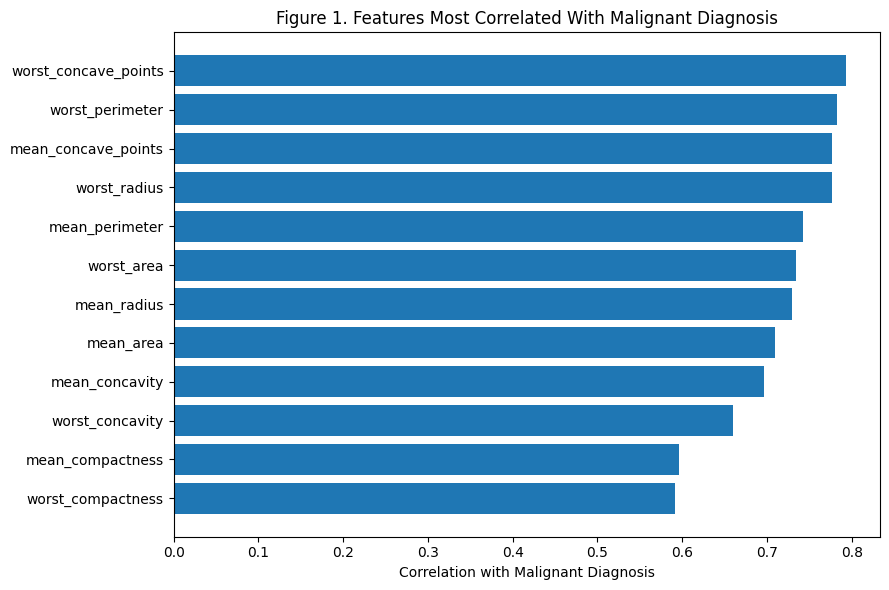

,feature,correlation_with_malignant
0,worst_compactness,0.590998
1,mean_compactness,0.596534
2,worst_concavity,0.659610
3,mean_concavity,0.696360
4,mean_area,0.708984
5,mean_radius,0.730029
6,worst_area,0.733825
7,mean_perimeter,0.742636
8,worst_radius,0.776454
9,mean_concave_points,0.776614


In [4]:
# Figure 1: Top correlations with malignant diagnosis
corr_with_target = df[feature_cols + [target_col]].corr()[target_col].drop(target_col)
top_corr = corr_with_target.abs().sort_values(ascending=False).head(12)
top_corr_signed = corr_with_target.loc[top_corr.index].sort_values()

plt.figure(figsize=(9, 6))
plt.barh(top_corr_signed.index, top_corr_signed.values)
plt.xlabel("Correlation with Malignant Diagnosis")
plt.title("Figure 1. Features Most Correlated With Malignant Diagnosis")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": top_corr_signed.index,
    "correlation_with_malignant": top_corr_signed.values
})


#### EDA note

The strongest relationships are expected to be tumor size and shape measurements. This matches what I found in earlier weeks. Logistic regression should be able to use these measurements to estimate the probability that a tumor is malignant.

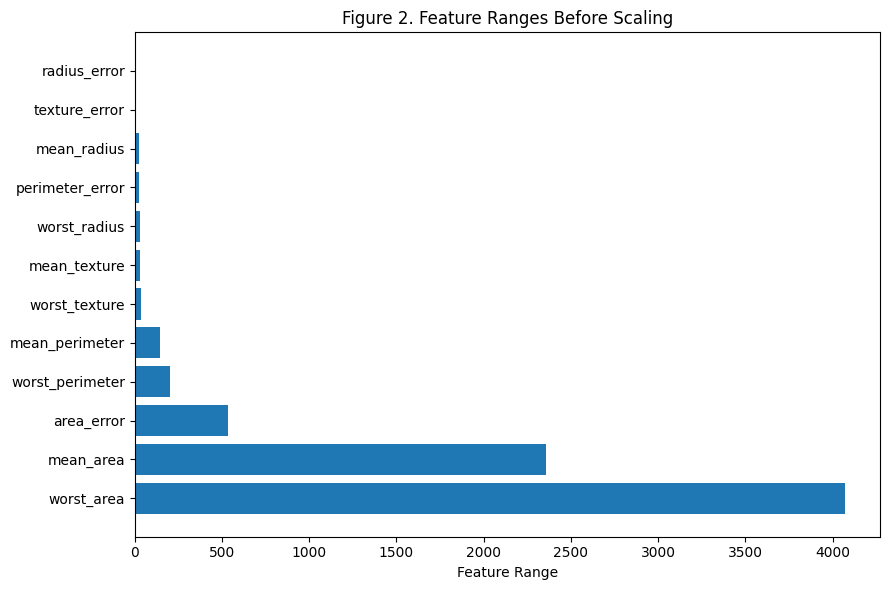

,min,max,mean,std,range
worst_area,185.2000,4254.000,880.583128,569.356993,4068.8000
mean_area,143.5000,2501.000,654.889104,351.914129,2357.5000
area_error,6.8020,542.200,40.337079,45.491006,535.3980
worst_perimeter,50.4100,251.200,107.261213,33.602542,200.7900
mean_perimeter,43.7900,188.500,91.969033,24.298981,144.7100
worst_texture,12.0200,49.540,25.677223,6.146258,37.5200
mean_texture,9.7100,39.280,19.289649,4.301036,29.5700
worst_radius,7.9300,36.040,16.269190,4.833242,28.1100
perimeter_error,0.7570,21.980,2.866059,2.021855,21.2230
mean_radius,6.9810,28.110,14.127292,3.524049,21.1290


In [5]:
# Figure 2: Feature scale comparison
# This shows why scaling matters. Some variables are much larger numerically than others.
scale_summary = X.agg(["min", "max", "mean", "std"]).T
scale_summary["range"] = scale_summary["max"] - scale_summary["min"]
scale_summary_sorted = scale_summary.sort_values("range", ascending=False).head(12)

plt.figure(figsize=(9, 6))
plt.barh(scale_summary_sorted.index, scale_summary_sorted["range"])
plt.xlabel("Feature Range")
plt.title("Figure 2. Feature Ranges Before Scaling")
plt.tight_layout()
plt.show()

scale_summary_sorted[["min", "max", "mean", "std", "range"]]


#### Scaling note

Feature scaling matters because tumor area has much larger values than variables like smoothness or symmetry. Logistic regression uses coefficients, and if features are on very different scales, the model can be harder to optimize and harder to compare. Scaling puts the features on a more similar scale.

### 1.4 Train-test split

I split the data into training and testing sets. I use stratification so the proportion of benign and malignant cases stays similar in both sets.

This helps me check whether the model works on data it has not already seen.

In [6]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

print("Training shape:", X_train.shape)
print("Testing shape:", X_test.shape)

print("Training target distribution:")
print(y_train.value_counts(normalize=True).round(3))

print("Testing target distribution:")
print(y_test.value_counts(normalize=True).round(3))


Training shape: (455, 30)
Testing shape: (114, 30)
Training target distribution:
diagnosis_malignant
0    0.626
1    0.374
Name: proportion, dtype: float64
Testing target distribution:
diagnosis_malignant
0    0.632
1    0.368
Name: proportion, dtype: float64


### 1.5 Evaluation function

For logistic regression, I am using classification metrics.

The main metrics I care about are:

- **Accuracy:** overall percent correct
- **Precision:** when the model predicts malignant, how often it is correct
- **Recall:** how many actual malignant cases the model catches
- **F1-score:** balance between precision and recall
- **ROC-AUC:** how well the model separates malignant vs. benign across thresholds

For this project, recall for malignant cases is especially important because missing a malignant tumor would be a serious concern.

In [7]:
def evaluate_classifier(name, model, X_train, X_test, y_train, y_test, threshold=0.50):
    """Fit a classifier and return evaluation metrics."""
    model.fit(X_train, y_train)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    train_pred = (train_prob >= threshold).astype(int)
    test_pred = (test_prob >= threshold).astype(int)

    results = {
        "model": name,
        "threshold": threshold,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision_malignant": precision_score(y_test, test_pred, pos_label=1),
        "test_recall_malignant": recall_score(y_test, test_pred, pos_label=1),
        "test_f1_malignant": f1_score(y_test, test_pred, pos_label=1),
        "test_roc_auc": roc_auc_score(y_test, test_prob)
    }

    return results, train_prob, test_prob, train_pred, test_pred


### 1.6 Logistic regression without scaling

First, I run logistic regression without scaling. This gives me a comparison point.

I expect the model may still perform well because this is a clean dataset, but scaling should make the model more stable and easier to interpret.

In [8]:
log_reg_no_scaling = Pipeline(steps=[
    ("model", LogisticRegression(max_iter=20000, random_state=42))
])

no_scaling_results, no_scaling_train_prob, no_scaling_test_prob, no_scaling_train_pred, no_scaling_test_pred = evaluate_classifier(
    "Logistic Regression: No Scaling",
    log_reg_no_scaling,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([no_scaling_results])


,model,threshold,train_accuracy,test_accuracy,test_precision_malignant,test_recall_malignant,test_f1_malignant,test_roc_auc
0,Logistic Regression: No Scaling,0.5,0.964835,0.938596,0.972973,0.857143,0.911392,0.992394


### 1.7 Logistic regression with standard scaling

Now I use `StandardScaler`, which transforms each feature so it has a mean of 0 and standard deviation of 1.

I use a pipeline because scaling should be fit only on the training data. This helps avoid data leakage.

In [9]:
log_reg_standard_scaled = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=20000, random_state=42))
])

standard_scaling_results, standard_train_prob, standard_test_prob, standard_train_pred, standard_test_pred = evaluate_classifier(
    "Logistic Regression: Standard Scaled",
    log_reg_standard_scaled,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([no_scaling_results, standard_scaling_results])


,model,threshold,train_accuracy,test_accuracy,test_precision_malignant,test_recall_malignant,test_f1_malignant,test_roc_auc
0,Logistic Regression: No Scaling,0.5,0.964835,0.938596,0.972973,0.857143,0.911392,0.992394
1,Logistic Regression: Standard Scaled,0.5,0.986813,0.964912,0.975000,0.928571,0.951220,0.996032


### 1.8 Logistic regression with min-max scaling

I also test `MinMaxScaler`, which changes the variables to a 0 to 1 range.

This is another way to scale features. I want to see if it performs differently from standard scaling.

In [10]:
log_reg_minmax_scaled = Pipeline(steps=[
    ("scaler", MinMaxScaler()),
    ("model", LogisticRegression(max_iter=20000, random_state=42))
])

minmax_results, minmax_train_prob, minmax_test_prob, minmax_train_pred, minmax_test_pred = evaluate_classifier(
    "Logistic Regression: Min-Max Scaled",
    log_reg_minmax_scaled,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([no_scaling_results, standard_scaling_results, minmax_results])


,model,threshold,train_accuracy,test_accuracy,test_precision_malignant,test_recall_malignant,test_f1_malignant,test_roc_auc
0,Logistic Regression: No Scaling,0.5,0.964835,0.938596,0.972973,0.857143,0.911392,0.992394
1,Logistic Regression: Standard Scaled,0.5,0.986813,0.964912,0.975000,0.928571,0.951220,0.996032
2,Logistic Regression: Min-Max Scaled,0.5,0.969231,0.973684,1.000000,0.928571,0.962963,0.998016


### 1.9 Compare scaling methods

This table and figure compare the logistic regression models with no scaling, standard scaling, and min-max scaling.

In [11]:
scaling_results_df = pd.DataFrame([
    no_scaling_results,
    standard_scaling_results,
    minmax_results
])

scaling_results_df.sort_values("test_roc_auc", ascending=False)


,model,threshold,train_accuracy,test_accuracy,test_precision_malignant,test_recall_malignant,test_f1_malignant,test_roc_auc
2,Logistic Regression: Min-Max Scaled,0.5,0.969231,0.973684,1.000000,0.928571,0.962963,0.998016
1,Logistic Regression: Standard Scaled,0.5,0.986813,0.964912,0.975000,0.928571,0.951220,0.996032
0,Logistic Regression: No Scaling,0.5,0.964835,0.938596,0.972973,0.857143,0.911392,0.992394


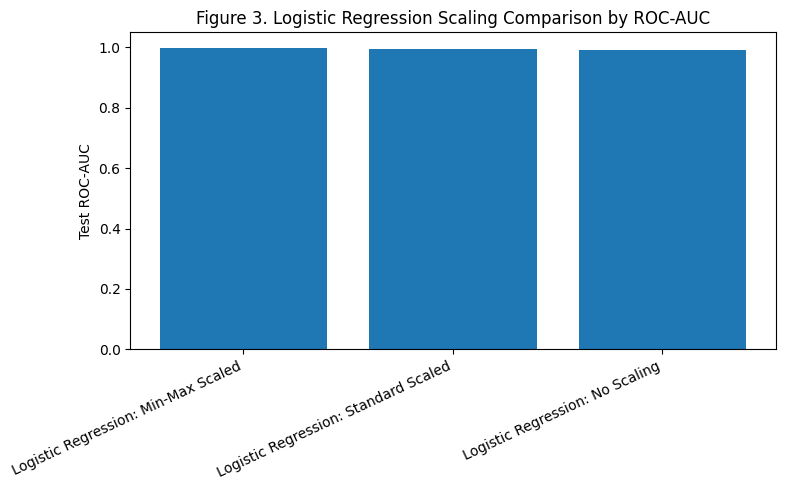

In [12]:
# Figure 3: Scaling comparison by ROC-AUC
plot_df = scaling_results_df.sort_values("test_roc_auc", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["test_roc_auc"])
plt.ylabel("Test ROC-AUC")
plt.title("Figure 3. Logistic Regression Scaling Comparison by ROC-AUC")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


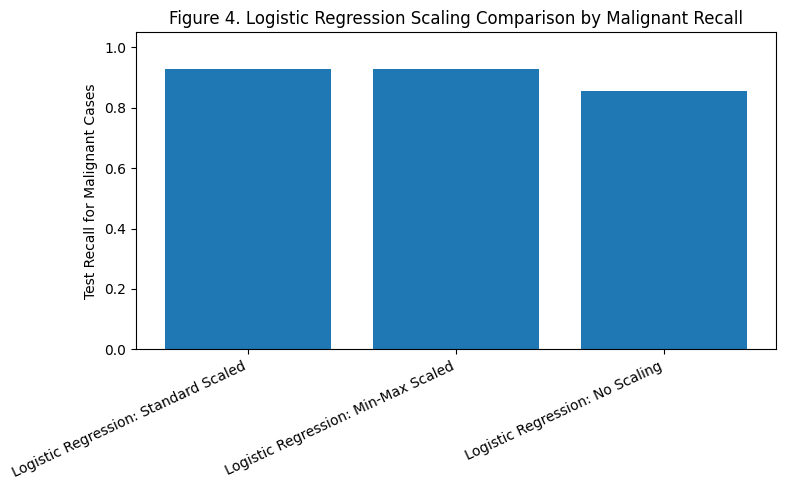

In [13]:
# Figure 4: Scaling comparison by malignant recall
plot_df = scaling_results_df.sort_values("test_recall_malignant", ascending=False)

plt.figure(figsize=(8, 5))
plt.bar(plot_df["model"], plot_df["test_recall_malignant"])
plt.ylabel("Test Recall for Malignant Cases")
plt.title("Figure 4. Logistic Regression Scaling Comparison by Malignant Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


#### Scaling interpretation

This section helps me understand whether scaling changed model performance. Even if the metrics are close, I still prefer scaling because it makes the model coefficients more comparable and helps the optimization process.

### 1.10 Hyperparameter tuning

Next, I tune the logistic regression model. The main hyperparameter I tune is `C`.

Important note:

- `C` is the inverse of regularization strength
- Smaller `C` means stronger regularization
- Larger `C` means weaker regularization

I also test `class_weight` because recall for malignant cases is important. Using `class_weight="balanced"` can make the model pay more attention to the smaller class.

In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

tuned_log_reg_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=20000, random_state=42, solver="liblinear"))
])

param_grid = {
    "model__C": np.logspace(-3, 3, 13),
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}

grid = GridSearchCV(
    estimator=tuned_log_reg_pipe,
    param_grid=param_grid,
    scoring="recall",
    cv=cv,
    n_jobs=-1
)

grid.fit(X_train, y_train)

print("Best parameters:")
print(grid.best_params_)
print("Best cross-validated recall:", grid.best_score_)


Best parameters:
{'model__C': np.float64(0.1), 'model__class_weight': 'balanced', 'model__penalty': 'l1'}
Best cross-validated recall: 0.9647058823529411


In [15]:
tuned_results, tuned_train_prob, tuned_test_prob, tuned_train_pred, tuned_test_pred = evaluate_classifier(
    "Tuned Logistic Regression",
    grid.best_estimator_,
    X_train,
    X_test,
    y_train,
    y_test
)

pd.DataFrame([standard_scaling_results, tuned_results])


,model,threshold,train_accuracy,test_accuracy,test_precision_malignant,test_recall_malignant,test_f1_malignant,test_roc_auc
0,Logistic Regression: Standard Scaled,0.5,0.986813,0.964912,0.97500,0.928571,0.951220,0.996032
1,Tuned Logistic Regression,0.5,0.973626,0.973684,0.97561,0.952381,0.963855,0.998016


#### Tuning interpretation

I used recall as the tuning metric because my project is healthcare-related. I would rather catch more malignant tumors, even if that means some benign tumors are flagged as malignant. In real clinical work, a false positive may lead to more testing, but a false negative could delay diagnosis.

### 1.11 Confusion matrix

The confusion matrix helps me see the actual prediction errors:

- True negative: benign correctly predicted as benign
- False positive: benign predicted as malignant
- False negative: malignant predicted as benign
- True positive: malignant correctly predicted as malignant

For this problem, I am especially watching false negatives.

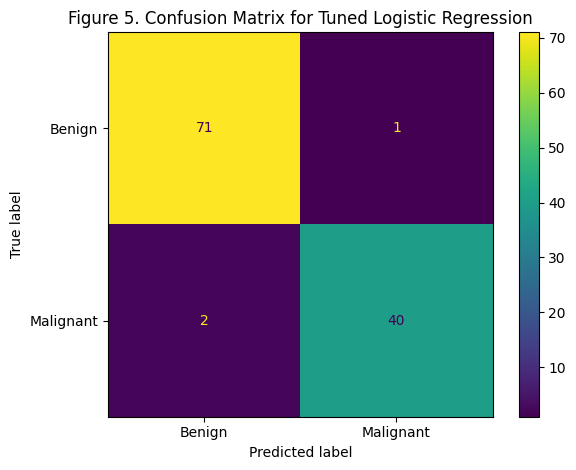

              precision    recall  f1-score   support

      Benign       0.97      0.99      0.98        72
   Malignant       0.98      0.95      0.96        42

    accuracy                           0.97       114
   macro avg       0.97      0.97      0.97       114
weighted avg       0.97      0.97      0.97       114



In [16]:
# Figure 5: Confusion matrix
cm = confusion_matrix(y_test, tuned_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Benign", "Malignant"]
)

disp.plot()
plt.title("Figure 5. Confusion Matrix for Tuned Logistic Regression")
plt.tight_layout()
plt.show()

print(classification_report(y_test, tuned_test_pred, target_names=["Benign", "Malignant"]))


### 1.12 ROC curve

The ROC curve shows how the model performs across different thresholds. The ROC-AUC score summarizes how well the model separates benign and malignant cases.

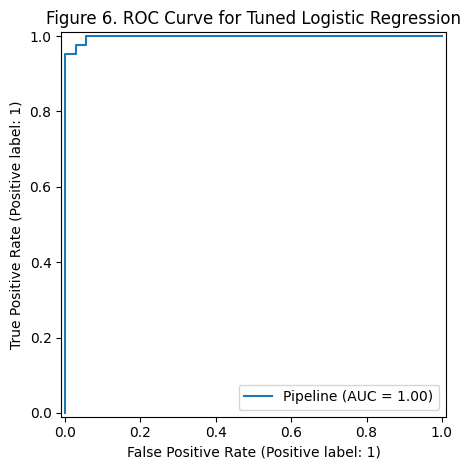

In [17]:
# Figure 6: ROC curve
RocCurveDisplay.from_estimator(
    grid.best_estimator_,
    X_test,
    y_test
)

plt.title("Figure 6. ROC Curve for Tuned Logistic Regression")
plt.tight_layout()
plt.show()


### 1.13 Threshold comparison

The default threshold is 0.50. This means the model predicts malignant if the predicted probability is at least 0.50.

For a healthcare problem, I may want a lower threshold so the model catches more malignant cases. The tradeoff is that lowering the threshold may increase false positives.

In [18]:
threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    pred = (tuned_test_prob >= threshold).astype(int)

    threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test, pred),
        "precision_malignant": precision_score(y_test, pred, pos_label=1, zero_division=0),
        "recall_malignant": recall_score(y_test, pred, pos_label=1),
        "f1_malignant": f1_score(y_test, pred, pos_label=1)
    })

threshold_df = pd.DataFrame(threshold_rows)
threshold_df.head()


,threshold,accuracy,precision_malignant,recall_malignant,f1_malignant
0,0.10,0.789474,0.636364,1.0,0.777778
1,0.15,0.850877,0.711864,1.0,0.831683
2,0.20,0.903509,0.792453,1.0,0.884211
3,0.25,0.929825,0.840000,1.0,0.913043
4,0.30,0.947368,0.875000,1.0,0.933333


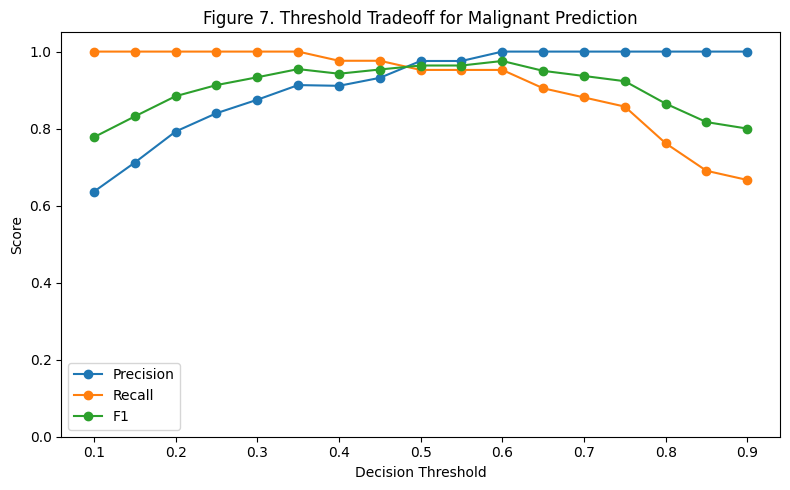

In [19]:
# Figure 7: Precision-recall tradeoff by threshold
plt.figure(figsize=(8, 5))
plt.plot(threshold_df["threshold"], threshold_df["precision_malignant"], marker="o", label="Precision")
plt.plot(threshold_df["threshold"], threshold_df["recall_malignant"], marker="o", label="Recall")
plt.plot(threshold_df["threshold"], threshold_df["f1_malignant"], marker="o", label="F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Figure 7. Threshold Tradeoff for Malignant Prediction")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


#### Threshold interpretation

This part helped me see that the cutoff matters. The model can produce probabilities, but I still have to decide what probability is high enough to call a tumor malignant. If the goal is to avoid missing malignant cases, I may choose a lower threshold than 0.50.

### 1.14 Coefficient interpretation

Because the tuned model uses scaling, I can compare coefficient sizes more fairly. Larger positive coefficients push the prediction toward malignant. Larger negative coefficients push the prediction toward benign.

This does not prove causation, but it helps me understand which features the model uses most.

In [20]:
best_model = grid.best_estimator_
coef_values = best_model.named_steps["model"].coef_[0]

coef_df = pd.DataFrame({
    "feature": feature_cols,
    "coefficient": coef_values,
    "abs_coefficient": np.abs(coef_values)
}).sort_values("abs_coefficient", ascending=False)

coef_df.head(15)


,feature,coefficient,abs_coefficient
20,worst_radius,2.065019,2.065019
7,mean_concave_points,0.846333,0.846333
21,worst_texture,0.738734,0.738734
27,worst_concave_points,0.606978,0.606978
10,radius_error,0.388270,0.388270
28,worst_symmetry,0.218818,0.218818
24,worst_smoothness,0.139588,0.139588
5,mean_compactness,0.000000,0.000000
8,mean_symmetry,0.000000,0.000000
4,mean_smoothness,0.000000,0.000000


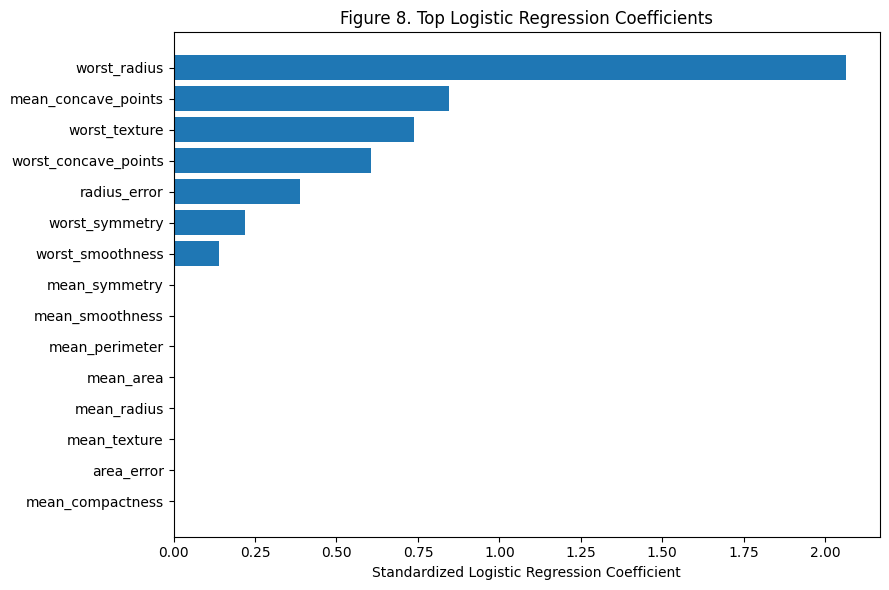

In [21]:
# Figure 8: Top logistic regression coefficients
top_coef = coef_df.head(15).sort_values("coefficient")

plt.figure(figsize=(9, 6))
plt.barh(top_coef["feature"], top_coef["coefficient"])
plt.xlabel("Standardized Logistic Regression Coefficient")
plt.title("Figure 8. Top Logistic Regression Coefficients")
plt.tight_layout()
plt.show()


#### Coefficient note

The coefficient results should be interpreted carefully because many tumor features are correlated. Still, this section is useful because it gives me a general idea of which measurements are pushing predictions toward malignant or benign.

### 1.15 Cross-validation comparison

I use cross-validation to compare the main models more fairly. This helps reduce the chance that I am choosing a model based only on one train-test split.

In [22]:
models_for_cv = {
    "No Scaling": log_reg_no_scaling,
    "Standard Scaling": log_reg_standard_scaled,
    "Min-Max Scaling": log_reg_minmax_scaled,
    "Tuned Standard Scaled": grid.best_estimator_
}

cv_summary = []

for name, model in models_for_cv.items():
    recall_scores = cross_val_score(model, X, y, cv=cv, scoring="recall")
    auc_scores = cross_val_score(model, X, y, cv=cv, scoring="roc_auc")
    accuracy_scores = cross_val_score(model, X, y, cv=cv, scoring="accuracy")

    cv_summary.append({
        "model": name,
        "CV_recall_mean": recall_scores.mean(),
        "CV_recall_std": recall_scores.std(),
        "CV_roc_auc_mean": auc_scores.mean(),
        "CV_roc_auc_std": auc_scores.std(),
        "CV_accuracy_mean": accuracy_scores.mean(),
        "CV_accuracy_std": accuracy_scores.std()
    })

cv_summary_df = pd.DataFrame(cv_summary).sort_values("CV_recall_mean", ascending=False)
cv_summary_df


,model,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std,CV_accuracy_mean,CV_accuracy_std
3,Tuned Standard Scaled,0.966999,0.024198,0.994203,0.005356,0.961388,0.018037
1,Standard Scaling,0.943632,0.052462,0.995314,0.005345,0.973669,0.016627
0,No Scaling,0.924585,0.053858,0.991637,0.004811,0.954339,0.018684
2,Min-Max Scaling,0.915282,0.061822,0.994394,0.005644,0.964866,0.019983


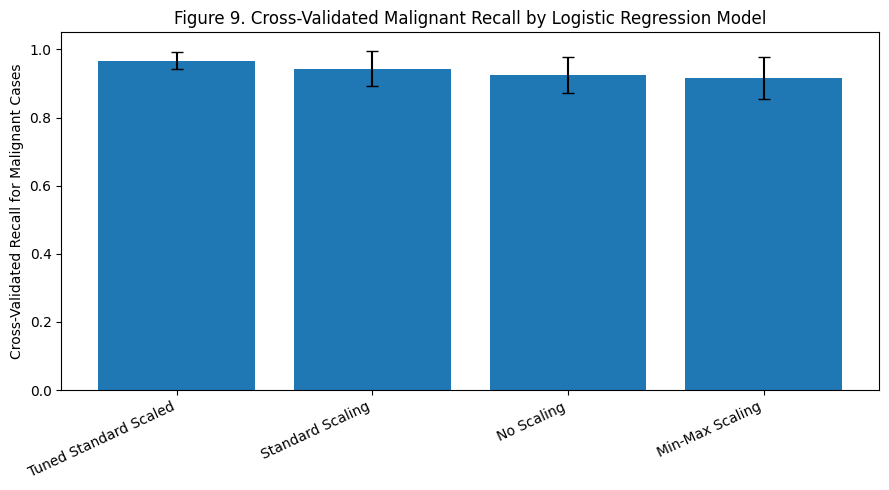

In [23]:
# Figure 9: Cross-validated recall comparison
plot_df = cv_summary_df.sort_values("CV_recall_mean", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["CV_recall_mean"], yerr=plot_df["CV_recall_std"], capsize=4)
plt.ylabel("Cross-Validated Recall for Malignant Cases")
plt.title("Figure 9. Cross-Validated Malignant Recall by Logistic Regression Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=25, ha="right")
plt.tight_layout()
plt.show()


### 1.16 Results summary for the milestone

This cell prints a short summary using the actual results from the notebook. I can use this later when I write Milestone One.

In [24]:
best_cv_model = cv_summary_df.sort_values("CV_recall_mean", ascending=False).iloc[0]

print("Week 4 Summary")
print("Best tuned logistic regression parameters:")
print(grid.best_params_)

print("Tuned model test results:")
print(f"Accuracy: {tuned_results['test_accuracy']:.4f}")
print(f"Precision for malignant: {tuned_results['test_precision_malignant']:.4f}")
print(f"Recall for malignant: {tuned_results['test_recall_malignant']:.4f}")
print(f"F1 for malignant: {tuned_results['test_f1_malignant']:.4f}")
print(f"ROC-AUC: {tuned_results['test_roc_auc']:.4f}")

print("Best model by cross-validated malignant recall:")
print(best_cv_model["model"])
print(f"CV Recall: {best_cv_model['CV_recall_mean']:.4f} ± {best_cv_model['CV_recall_std']:.4f}")
print(f"CV ROC-AUC: {best_cv_model['CV_roc_auc_mean']:.4f} ± {best_cv_model['CV_roc_auc_std']:.4f}")

print("Top 5 coefficient features in tuned logistic regression:")
for feature in coef_df.head(5)["feature"]:
    print("-", feature)


Week 4 Summary
Best tuned logistic regression parameters:
{'model__C': np.float64(0.1), 'model__class_weight': 'balanced', 'model__penalty': 'l1'}
Tuned model test results:
Accuracy: 0.9737
Precision for malignant: 0.9756
Recall for malignant: 0.9524
F1 for malignant: 0.9639
ROC-AUC: 0.9980
Best model by cross-validated malignant recall:
Tuned Standard Scaled
CV Recall: 0.9670 ± 0.0242
CV ROC-AUC: 0.9942 ± 0.0054
Top 5 coefficient features in tuned logistic regression:
- worst_radius
- mean_concave_points
- worst_texture
- worst_concave_points
- radius_error


### 1.17 Part 1 summary: Wisconsin

After running the Wisconsin analysis, I found that logistic regression is a better match for my project than the linear regression models from earlier weeks because my outcome is binary. The model is trying to predict whether a tumor is malignant or benign, so logistic regression makes more sense.

Feature scaling was important because the tumor variables are measured on very different scales. For example, area has much larger numbers than smoothness. Scaling helped put the features on a similar scale, which made the logistic regression model easier to fit and easier to interpret. Even if the performance difference between scaled and unscaled models was not huge, I still think scaling is the better approach for this dataset.

The tuned logistic regression model helped me understand the role of regularization. The `C` value controlled how strongly the model was regularized. A smaller `C` means stronger regularization, while a larger `C` means weaker regularization. I also tested class weighting because malignant recall matters in this project.

The confusion matrix was useful because it showed the types of mistakes the model made. In this healthcare setting, false negatives are especially important because that would mean a malignant tumor was predicted as benign. Because of that, I focused more on recall for malignant cases instead of only looking at accuracy.

The ROC curve and ROC-AUC score showed how well the model separated benign and malignant tumors across different thresholds. The threshold analysis also helped me see that the default 0.50 cutoff is not the only option. If the goal is to catch as many malignant cases as possible, a lower threshold may be reasonable, but it could also increase false positives.

Overall, Week 4 supported my earlier findings that tumor characteristics are strongly related to diagnosis. Logistic regression gave me a more appropriate classification model and showed that feature scaling, tuning, and threshold choice all affect how the model performs. This is important for my capstone because I want the final model to be accurate but also clinically meaningful.

## Part 2 — Breast Cancer Coimbra

The second dataset is the **Breast Cancer Coimbra** dataset. It is also about breast cancer, but it uses a different kind of healthcare information than Wisconsin. Instead of tumor image measurements, it uses clinical and blood-based predictors such as age, BMI, glucose, insulin, HOMA, leptin, adiponectin, resistin, and MCP-1. The outcome is binary (`1 = breast cancer patient`, `0 = healthy control`), so logistic regression applies here just as it does for Wisconsin.

I do not merge the two datasets, because they do not share the same patients or the same variables. I run the same Week 4 methods on each dataset separately and compare them in Part 3. Coimbra is also much smaller (116 rows, 9 predictors), so its results are more sensitive to the train-test split, which is why cross-validation matters more here.

**Setup — repeated imports.** The imports are repeated below so this part can be run on its own, even if the notebook is started from here.

In [25]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    classification_report
)


### 2.1 Load and prepare the data

The Coimbra dataset target is called `Classification`.

The original coding is:

- `1 = Healthy controls`
- `2 = Patients with breast cancer`

For consistency with the rest of my project, I create:

- `breast_cancer_present = 1` for breast cancer patients
- `breast_cancer_present = 0` for healthy controls

This makes interpretation easier because a higher predicted probability means the model is leaning toward breast cancer being present.

In [26]:
coimbra_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00451/dataR2.csv"

coimbra_df = pd.read_csv(coimbra_url)

coimbra_df.columns = (
    coimbra_df.columns
    .str.strip()
    .str.replace(" ", "_")
    .str.replace("-", "_")
    .str.replace(".", "_", regex=False)
)

coimbra_df["breast_cancer_present"] = (coimbra_df["Classification"] == 2).astype(int)
coimbra_df["diagnosis_group"] = np.where(coimbra_df["breast_cancer_present"] == 1, "Patient", "Healthy Control")

print("Coimbra dataset shape:", coimbra_df.shape)
print("\nClass counts:")
print(coimbra_df["diagnosis_group"].value_counts())

print("\nClass percentages:")
print(coimbra_df["diagnosis_group"].value_counts(normalize=True).round(3))

print("\nMissing values:")
print(coimbra_df.isna().sum())

coimbra_df.head()


Coimbra dataset shape: (116, 12)

Class counts:
diagnosis_group
Patient            64
Healthy Control    52
Name: count, dtype: int64

Class percentages:
diagnosis_group
Patient            0.552
Healthy Control    0.448
Name: proportion, dtype: float64

Missing values:
Age                      0
BMI                      0
Glucose                  0
Insulin                  0
HOMA                     0
Leptin                   0
Adiponectin              0
Resistin                 0
MCP_1                    0
Classification           0
breast_cancer_present    0
diagnosis_group          0
dtype: int64


,Age,BMI,Glucose,Insulin,HOMA,Leptin,Adiponectin,Resistin,MCP_1,Classification,breast_cancer_present,diagnosis_group
0,48,23.500000,70,2.707,0.467409,8.8071,9.702400,7.99585,417.114,1,0,Healthy Control
1,83,20.690495,92,3.115,0.706897,8.8438,5.429285,4.06405,468.786,1,0,Healthy Control
2,82,23.124670,91,4.498,1.009651,17.9393,22.432040,9.27715,554.697,1,0,Healthy Control
3,68,21.367521,77,3.226,0.612725,9.8827,7.169560,12.76600,928.220,1,0,Healthy Control
4,86,21.111111,92,3.549,0.805386,6.6994,4.819240,10.57635,773.920,1,0,Healthy Control


### 2.2 Features and target

The Coimbra dataset has 9 predictors. These predictors are clinical and blood-based rather than tumor image measurements.

Because this dataset is smaller than Wisconsin, I expect the model results to be more sensitive to the train-test split. This is why I use cross-validation later.

In [27]:
coimbra_target = "breast_cancer_present"
coimbra_label = "diagnosis_group"

coimbra_features = [
    col for col in coimbra_df.columns
    if col not in ["Classification", coimbra_target, coimbra_label]
]

X_coimbra = coimbra_df[coimbra_features]
y_coimbra = coimbra_df[coimbra_target]

print("Coimbra features:")
print(coimbra_features)

print("\nNumber of rows:", X_coimbra.shape[0])
print("Number of features:", X_coimbra.shape[1])


Coimbra features:
['Age', 'BMI', 'Glucose', 'Insulin', 'HOMA', 'Leptin', 'Adiponectin', 'Resistin', 'MCP_1']

Number of rows: 116
Number of features: 9


### 2.3 Exploratory analysis

Before running logistic regression, I want to look at how the predictors differ between patients and healthy controls. This helps me connect the model back to the data instead of just running it by default.

In [28]:
coimbra_group_means = coimbra_df.groupby("diagnosis_group")[coimbra_features].mean().T
coimbra_group_means["difference_patient_minus_control"] = (
    coimbra_group_means["Patient"] - coimbra_group_means["Healthy Control"]
)

coimbra_group_means.sort_values("difference_patient_minus_control")


diagnosis_group,Healthy Control,Patient,difference_patient_minus_control
Age,58.076923,56.671875,-1.405048
BMI,28.317336,26.984740,-1.332596
Adiponectin,10.328205,10.061167,-0.267038
Leptin,26.637933,26.596512,-0.041420
HOMA,1.552398,3.623342,2.070944
Insulin,6.933769,12.513219,5.579450
Resistin,11.614813,17.253777,5.638964
Glucose,88.230769,105.562500,17.331731
MCP_1,499.730692,563.016500,63.285808


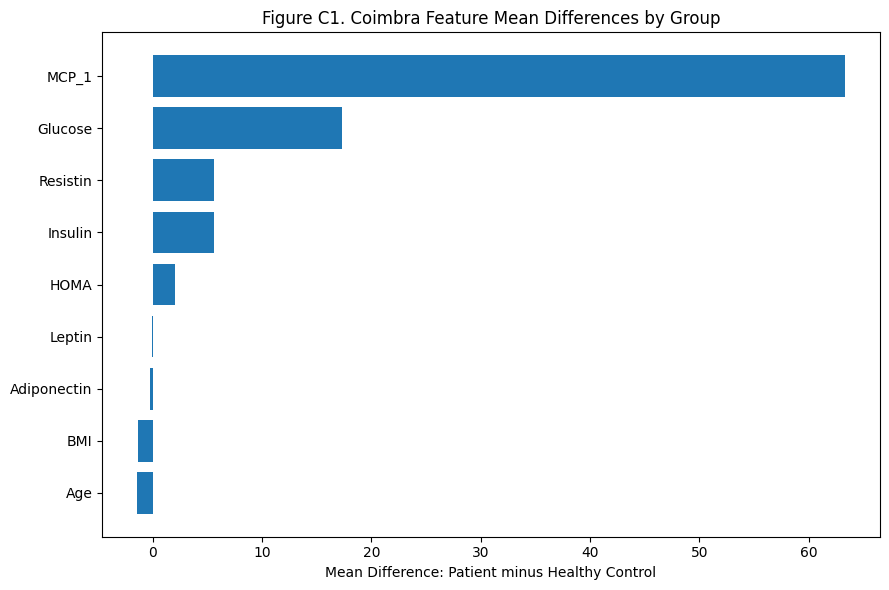

In [29]:
# Figure C1: Coimbra feature mean differences
plot_df = coimbra_group_means.sort_values("difference_patient_minus_control")

plt.figure(figsize=(9, 6))
plt.barh(plot_df.index, plot_df["difference_patient_minus_control"])
plt.xlabel("Mean Difference: Patient minus Healthy Control")
plt.title("Figure C1. Coimbra Feature Mean Differences by Group")
plt.tight_layout()
plt.show()


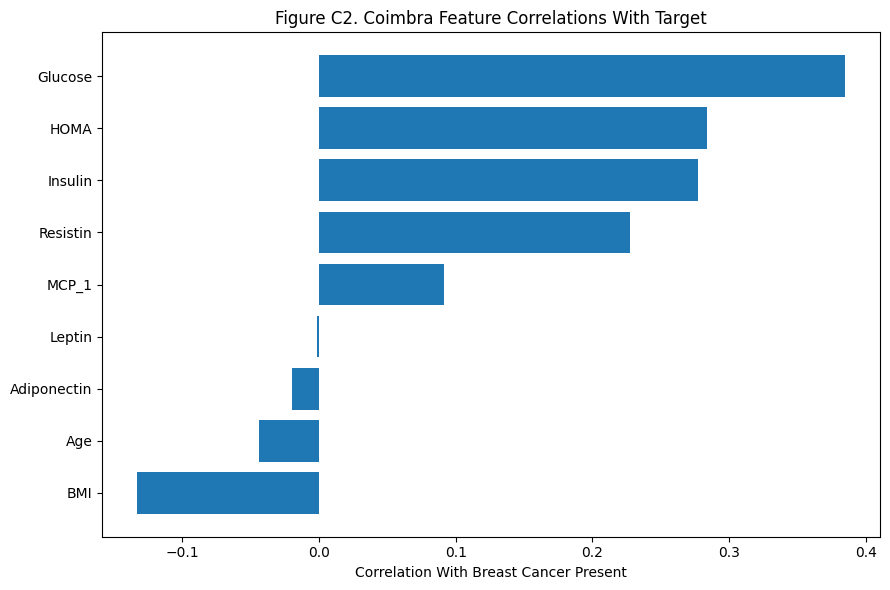

,feature,correlation_with_breast_cancer_present
0,BMI,-0.132586
1,Age,-0.043555
2,Adiponectin,-0.019490
3,Leptin,-0.001078
4,MCP_1,0.091381
5,Resistin,0.227310
6,Insulin,0.276804
7,HOMA,0.284012
8,Glucose,0.384315


In [30]:
# Figure C2: Coimbra correlations with breast cancer status
coimbra_corr_with_target = coimbra_df[coimbra_features + [coimbra_target]].corr()[coimbra_target].drop(coimbra_target)
coimbra_corr_sorted = coimbra_corr_with_target.sort_values()

plt.figure(figsize=(9, 6))
plt.barh(coimbra_corr_sorted.index, coimbra_corr_sorted.values)
plt.xlabel("Correlation With Breast Cancer Present")
plt.title("Figure C2. Coimbra Feature Correlations With Target")
plt.tight_layout()
plt.show()

pd.DataFrame({
    "feature": coimbra_corr_sorted.index,
    "correlation_with_breast_cancer_present": coimbra_corr_sorted.values
})


#### Coimbra EDA note

The Coimbra dataset is different from Wisconsin because the predictors are more indirect. Wisconsin uses tumor measurements, while Coimbra uses clinical and blood-based markers. Because of this, I expect Coimbra to be harder to predict than Wisconsin.

The EDA still helps because it shows which variables appear most different between patients and healthy controls. It also reminds me why scaling matters: features such as MCP-1, insulin, glucose, and BMI are on very different numeric scales.

### 2.4 Feature scaling check

Logistic regression can be affected by feature scale, especially when regularization is used. Since Coimbra features have very different ranges, I compare models with no scaling, standard scaling, and min-max scaling.

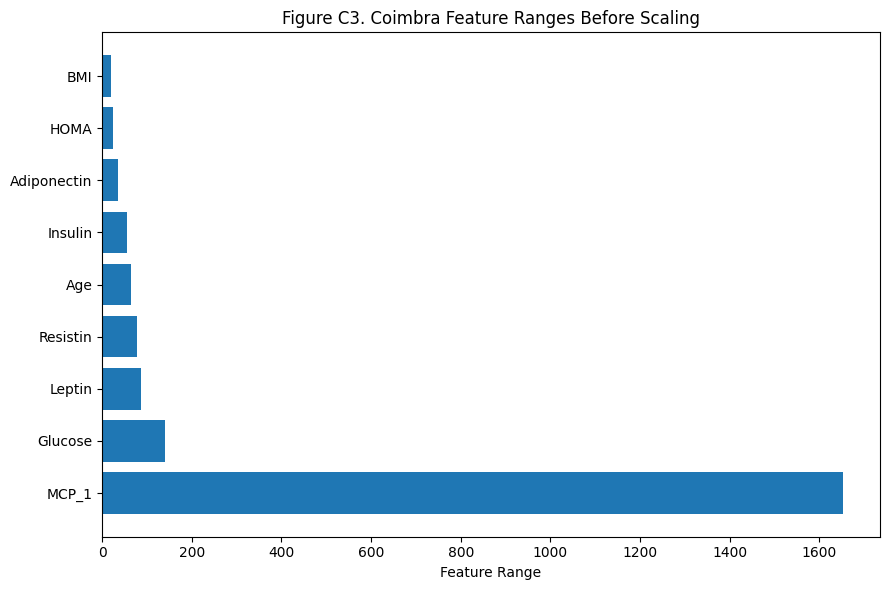

,min,max,mean,std,range
MCP_1,45.843000,1698.440000,534.647000,345.912663,1652.597000
Glucose,60.000000,201.000000,97.793103,22.525162,141.000000
Leptin,4.311000,90.280000,26.615080,19.183294,85.969000
Resistin,3.210000,82.100000,14.725966,12.390646,78.890000
Age,24.000000,89.000000,57.301724,16.112766,65.000000
Insulin,2.432000,58.460000,10.012086,10.067768,56.028000
Adiponectin,1.656020,38.040000,10.180874,6.843341,36.383980
HOMA,0.467409,25.050342,2.694988,3.642043,24.582933
BMI,18.370000,38.578759,27.582111,5.020136,20.208759


In [31]:
scale_summary_c = X_coimbra.agg(["min", "max", "mean", "std"]).T
scale_summary_c["range"] = scale_summary_c["max"] - scale_summary_c["min"]
scale_summary_c = scale_summary_c.sort_values("range", ascending=False)

plt.figure(figsize=(9, 6))
plt.barh(scale_summary_c.index, scale_summary_c["range"])
plt.xlabel("Feature Range")
plt.title("Figure C3. Coimbra Feature Ranges Before Scaling")
plt.tight_layout()
plt.show()

scale_summary_c[["min", "max", "mean", "std", "range"]]


### 2.5 Train-test split

I use a stratified train-test split so the training and test sets have similar proportions of patients and healthy controls.

In [32]:
X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_coimbra,
    y_coimbra,
    test_size=0.20,
    random_state=42,
    stratify=y_coimbra
)

print("Training shape:", X_train_c.shape)
print("Testing shape:", X_test_c.shape)

print("\nTraining target distribution:")
print(y_train_c.value_counts(normalize=True).round(3))

print("\nTesting target distribution:")
print(y_test_c.value_counts(normalize=True).round(3))


Training shape: (92, 9)
Testing shape: (24, 9)

Training target distribution:
breast_cancer_present
1    0.554
0    0.446
Name: proportion, dtype: float64

Testing target distribution:
breast_cancer_present
1    0.542
0    0.458
Name: proportion, dtype: float64


### 2.6 Evaluation function

For Week 4, I use classification metrics because logistic regression is a classification model.

The main metrics are:

- Accuracy
- Precision for breast cancer patients
- Recall for breast cancer patients
- F1-score
- ROC-AUC

I pay close attention to recall because, in a healthcare context, missing a breast cancer case would be a serious concern.

In [33]:
def evaluate_classifier_c(name, model, X_train, X_test, y_train, y_test, threshold=0.50):
    model.fit(X_train, y_train)

    train_prob = model.predict_proba(X_train)[:, 1]
    test_prob = model.predict_proba(X_test)[:, 1]

    train_pred = (train_prob >= threshold).astype(int)
    test_pred = (test_prob >= threshold).astype(int)

    results = {
        "model": name,
        "threshold": threshold,
        "train_accuracy": accuracy_score(y_train, train_pred),
        "test_accuracy": accuracy_score(y_test, test_pred),
        "test_precision_patient": precision_score(y_test, test_pred, pos_label=1, zero_division=0),
        "test_recall_patient": recall_score(y_test, test_pred, pos_label=1),
        "test_f1_patient": f1_score(y_test, test_pred, pos_label=1),
        "test_roc_auc": roc_auc_score(y_test, test_prob)
    }

    return results, train_prob, test_prob, train_pred, test_pred


### 2.7 Logistic regression without scaling

I first run logistic regression without scaling. This gives me a baseline to compare against scaled models.

In [34]:
coimbra_log_reg_no_scaling = Pipeline(steps=[
    ("model", LogisticRegression(max_iter=20000, random_state=42))
])

coimbra_no_scaling_results, coimbra_no_scaling_train_prob, coimbra_no_scaling_test_prob, coimbra_no_scaling_train_pred, coimbra_no_scaling_test_pred = evaluate_classifier_c(
    "Coimbra Logistic Regression: No Scaling",
    coimbra_log_reg_no_scaling,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_no_scaling_results])


,model,threshold,train_accuracy,test_accuracy,test_precision_patient,test_recall_patient,test_f1_patient,test_roc_auc
0,Coimbra Logistic Regression: No Scaling,0.5,0.771739,0.75,0.818182,0.692308,0.75,0.769231


### 2.8 Logistic regression with standard scaling

Now I use `StandardScaler`, which gives each feature a mean of 0 and standard deviation of 1. This is useful because the Coimbra features are measured on very different scales.

In [35]:
coimbra_log_reg_standard = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=20000, random_state=42))
])

coimbra_standard_results, coimbra_standard_train_prob, coimbra_standard_test_prob, coimbra_standard_train_pred, coimbra_standard_test_pred = evaluate_classifier_c(
    "Coimbra Logistic Regression: Standard Scaled",
    coimbra_log_reg_standard,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_no_scaling_results, coimbra_standard_results])


,model,threshold,train_accuracy,test_accuracy,test_precision_patient,test_recall_patient,test_f1_patient,test_roc_auc
0,Coimbra Logistic Regression: No Scaling,0.5,0.771739,0.750000,0.818182,0.692308,0.75,0.769231
1,Coimbra Logistic Regression: Standard Scaled,0.5,0.793478,0.791667,0.833333,0.769231,0.80,0.769231


### 2.9 Min-max scaling and scaling comparison

I also test `MinMaxScaler`, which transforms values to a 0 to 1 range. This gives me another way to compare scaling methods.

In [36]:
coimbra_log_reg_minmax = Pipeline(steps=[
    ("scaler", MinMaxScaler()),
    ("model", LogisticRegression(max_iter=20000, random_state=42))
])

coimbra_minmax_results, coimbra_minmax_train_prob, coimbra_minmax_test_prob, coimbra_minmax_train_pred, coimbra_minmax_test_pred = evaluate_classifier_c(
    "Coimbra Logistic Regression: Min-Max Scaled",
    coimbra_log_reg_minmax,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

coimbra_scaling_results_df = pd.DataFrame([
    coimbra_no_scaling_results,
    coimbra_standard_results,
    coimbra_minmax_results
])

coimbra_scaling_results_df.sort_values("test_roc_auc", ascending=False)


,model,threshold,train_accuracy,test_accuracy,test_precision_patient,test_recall_patient,test_f1_patient,test_roc_auc
0,Coimbra Logistic Regression: No Scaling,0.5,0.771739,0.750000,0.818182,0.692308,0.750000,0.769231
1,Coimbra Logistic Regression: Standard Scaled,0.5,0.793478,0.791667,0.833333,0.769231,0.800000,0.769231
2,Coimbra Logistic Regression: Min-Max Scaled,0.5,0.760870,0.666667,0.692308,0.692308,0.692308,0.755245


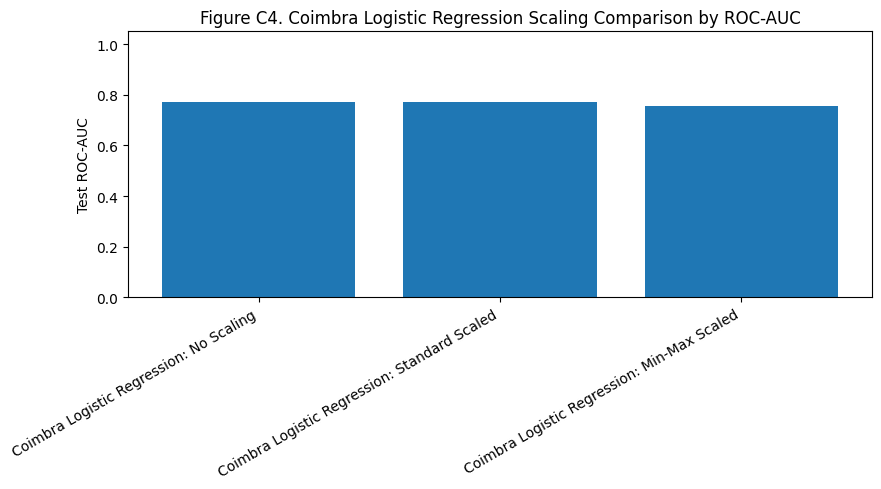

In [37]:
# Figure C4: Coimbra scaling comparison by ROC-AUC
plot_df = coimbra_scaling_results_df.sort_values("test_roc_auc", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["test_roc_auc"])
plt.ylabel("Test ROC-AUC")
plt.title("Figure C4. Coimbra Logistic Regression Scaling Comparison by ROC-AUC")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


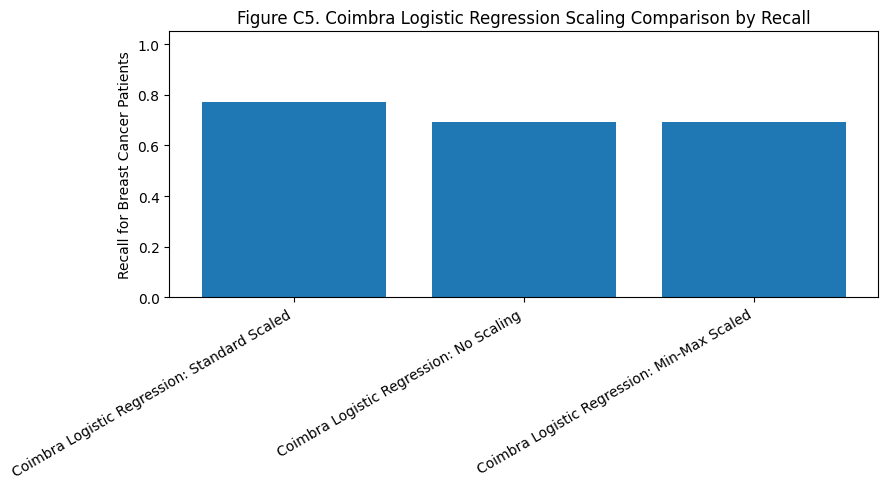

In [38]:
# Figure C5: Coimbra scaling comparison by recall
plot_df = coimbra_scaling_results_df.sort_values("test_recall_patient", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["test_recall_patient"])
plt.ylabel("Recall for Breast Cancer Patients")
plt.title("Figure C5. Coimbra Logistic Regression Scaling Comparison by Recall")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


#### Coimbra scaling interpretation

This comparison helps me see whether scaling improved logistic regression performance. Even if the performance numbers are close, I still prefer scaling because it makes regularized logistic regression more appropriate and makes the coefficients more comparable.

### 2.10 Hyperparameter tuning

Next, I tune the standard-scaled logistic regression model.

I tune:

- `C`: inverse of regularization strength
- `penalty`: L1 or L2 regularization
- `class_weight`: whether to balance class weights

A smaller `C` means stronger regularization. A larger `C` means weaker regularization. I use recall as the tuning metric because I care about identifying breast cancer patients.

In [39]:
cv_c = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

coimbra_tuned_pipe = Pipeline(steps=[
    ("scaler", StandardScaler()),
    ("model", LogisticRegression(max_iter=20000, random_state=42, solver="liblinear"))
])

coimbra_param_grid = {
    "model__C": np.logspace(-3, 3, 13),
    "model__penalty": ["l1", "l2"],
    "model__class_weight": [None, "balanced"]
}

coimbra_grid = GridSearchCV(
    estimator=coimbra_tuned_pipe,
    param_grid=coimbra_param_grid,
    scoring="recall",
    cv=cv_c,
    n_jobs=-1
)

coimbra_grid.fit(X_train_c, y_train_c)

print("Best Coimbra parameters:")
print(coimbra_grid.best_params_)
print("\nBest cross-validated recall:", coimbra_grid.best_score_)


Best Coimbra parameters:
{'model__C': np.float64(1.0), 'model__class_weight': None, 'model__penalty': 'l2'}

Best cross-validated recall: 0.7854545454545455


In [40]:
coimbra_tuned_results, coimbra_tuned_train_prob, coimbra_tuned_test_prob, coimbra_tuned_train_pred, coimbra_tuned_test_pred = evaluate_classifier_c(
    "Coimbra Tuned Logistic Regression",
    coimbra_grid.best_estimator_,
    X_train_c,
    X_test_c,
    y_train_c,
    y_test_c
)

pd.DataFrame([coimbra_standard_results, coimbra_tuned_results])


,model,threshold,train_accuracy,test_accuracy,test_precision_patient,test_recall_patient,test_f1_patient,test_roc_auc
0,Coimbra Logistic Regression: Standard Scaled,0.5,0.793478,0.791667,0.833333,0.769231,0.80,0.769231
1,Coimbra Tuned Logistic Regression,0.5,0.793478,0.750000,0.818182,0.692308,0.75,0.769231


### 2.11 Confusion matrix

The confusion matrix shows the actual prediction errors. For this project, I especially care about false negatives because that would mean a breast cancer patient was predicted as a healthy control.

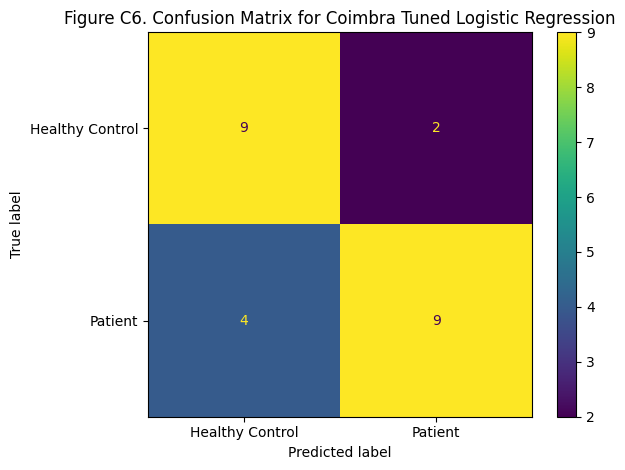

                 precision    recall  f1-score   support

Healthy Control       0.69      0.82      0.75        11
        Patient       0.82      0.69      0.75        13

       accuracy                           0.75        24
      macro avg       0.76      0.76      0.75        24
   weighted avg       0.76      0.75      0.75        24



In [41]:
cm_c = confusion_matrix(y_test_c, coimbra_tuned_test_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm_c,
    display_labels=["Healthy Control", "Patient"]
)

disp.plot()
plt.title("Figure C6. Confusion Matrix for Coimbra Tuned Logistic Regression")
plt.tight_layout()
plt.show()

print(classification_report(y_test_c, coimbra_tuned_test_pred, target_names=["Healthy Control", "Patient"]))


### 2.12 ROC curve

The ROC curve shows how well the tuned logistic regression model separates patients from healthy controls across thresholds.

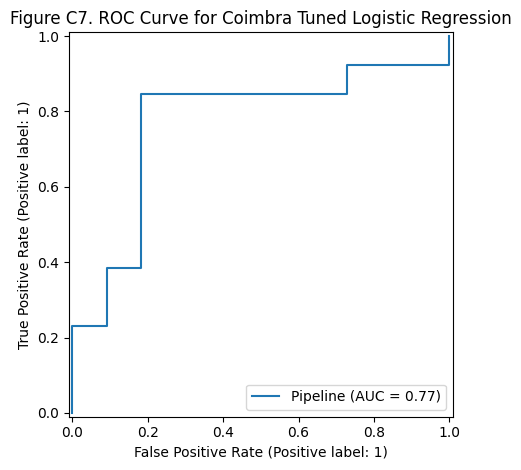

In [42]:
RocCurveDisplay.from_estimator(
    coimbra_grid.best_estimator_,
    X_test_c,
    y_test_c
)

plt.title("Figure C7. ROC Curve for Coimbra Tuned Logistic Regression")
plt.tight_layout()
plt.show()


### 2.13 Threshold comparison

The default threshold is 0.50. Since this is a healthcare-related project, I also test other thresholds to see how precision and recall change.

A lower threshold may catch more patients, but it can also increase false positives.

In [43]:
coimbra_threshold_rows = []

for threshold in np.arange(0.10, 0.91, 0.05):
    pred = (coimbra_tuned_test_prob >= threshold).astype(int)

    coimbra_threshold_rows.append({
        "threshold": threshold,
        "accuracy": accuracy_score(y_test_c, pred),
        "precision_patient": precision_score(y_test_c, pred, pos_label=1, zero_division=0),
        "recall_patient": recall_score(y_test_c, pred, pos_label=1),
        "f1_patient": f1_score(y_test_c, pred, pos_label=1)
    })

coimbra_threshold_df = pd.DataFrame(coimbra_threshold_rows)
coimbra_threshold_df.head()


,threshold,accuracy,precision_patient,recall_patient,f1_patient
0,0.10,0.500000,0.521739,0.923077,0.666667
1,0.15,0.500000,0.521739,0.923077,0.666667
2,0.20,0.541667,0.545455,0.923077,0.685714
3,0.25,0.541667,0.545455,0.923077,0.685714
4,0.30,0.625000,0.611111,0.846154,0.709677


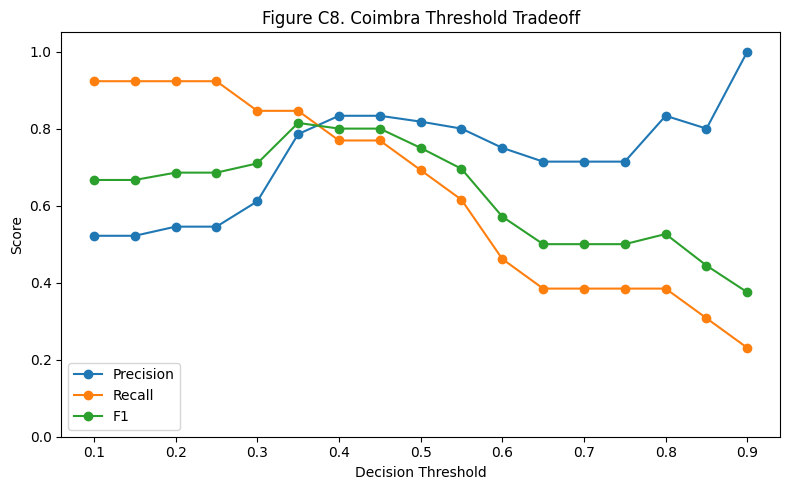

In [44]:
# Figure C8: Coimbra threshold tradeoff
plt.figure(figsize=(8, 5))
plt.plot(coimbra_threshold_df["threshold"], coimbra_threshold_df["precision_patient"], marker="o", label="Precision")
plt.plot(coimbra_threshold_df["threshold"], coimbra_threshold_df["recall_patient"], marker="o", label="Recall")
plt.plot(coimbra_threshold_df["threshold"], coimbra_threshold_df["f1_patient"], marker="o", label="F1")
plt.xlabel("Decision Threshold")
plt.ylabel("Score")
plt.title("Figure C8. Coimbra Threshold Tradeoff")
plt.ylim(0, 1.05)
plt.legend()
plt.tight_layout()
plt.show()


### 2.14 Coefficient interpretation

Because the tuned model uses scaling, I can compare coefficient sizes more fairly. Positive coefficients push the prediction toward breast cancer being present. Negative coefficients push the prediction toward healthy control.

In [45]:
coimbra_best_model = coimbra_grid.best_estimator_
coimbra_coef_values = coimbra_best_model.named_steps["model"].coef_[0]

coimbra_coef_df = pd.DataFrame({
    "feature": coimbra_features,
    "coefficient": coimbra_coef_values,
    "abs_coefficient": np.abs(coimbra_coef_values)
}).sort_values("abs_coefficient", ascending=False)

coimbra_coef_df


,feature,coefficient,abs_coefficient
2,Glucose,1.809846,1.809846
7,Resistin,0.574864,0.574864
5,Leptin,-0.474616,0.474616
1,BMI,-0.402344,0.402344
3,Insulin,0.323799,0.323799
4,HOMA,0.290240,0.290240
0,Age,-0.239518,0.239518
6,Adiponectin,-0.030548,0.030548
8,MCP_1,0.024770,0.024770


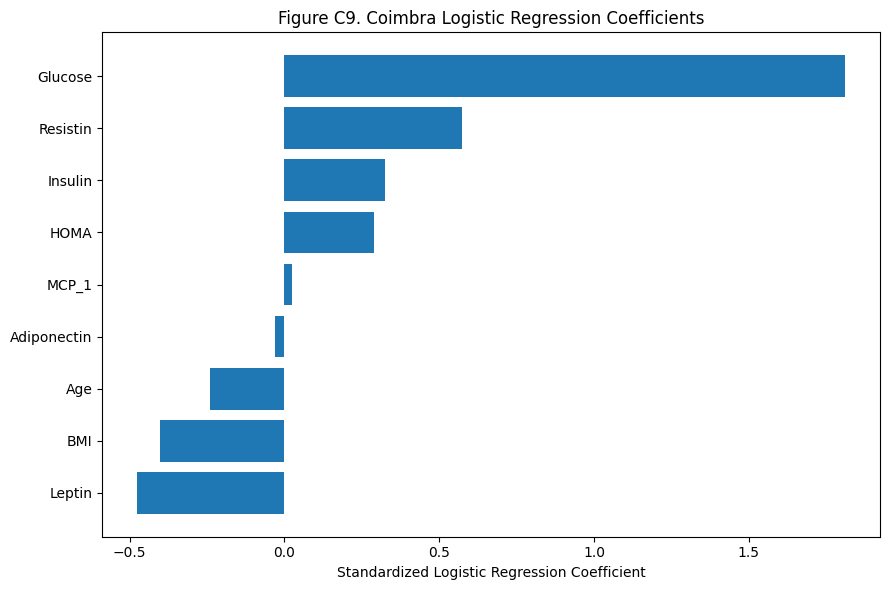

In [46]:
# Figure C9: Coimbra logistic regression coefficients
plot_df = coimbra_coef_df.sort_values("coefficient")

plt.figure(figsize=(9, 6))
plt.barh(plot_df["feature"], plot_df["coefficient"])
plt.xlabel("Standardized Logistic Regression Coefficient")
plt.title("Figure C9. Coimbra Logistic Regression Coefficients")
plt.tight_layout()
plt.show()


### 2.15 Cross-validation comparison

Since the Coimbra dataset is small, cross-validation is important. It gives a more stable view of performance than one train-test split alone.

In [47]:
coimbra_models_for_cv = {
    "No Scaling": coimbra_log_reg_no_scaling,
    "Standard Scaling": coimbra_log_reg_standard,
    "Min-Max Scaling": coimbra_log_reg_minmax,
    "Tuned Standard Scaled": coimbra_grid.best_estimator_
}

coimbra_cv_summary = []

for name, model in coimbra_models_for_cv.items():
    recall_scores = cross_val_score(model, X_coimbra, y_coimbra, cv=cv_c, scoring="recall")
    auc_scores = cross_val_score(model, X_coimbra, y_coimbra, cv=cv_c, scoring="roc_auc")
    accuracy_scores = cross_val_score(model, X_coimbra, y_coimbra, cv=cv_c, scoring="accuracy")

    coimbra_cv_summary.append({
        "model": name,
        "CV_recall_mean": recall_scores.mean(),
        "CV_recall_std": recall_scores.std(),
        "CV_roc_auc_mean": auc_scores.mean(),
        "CV_roc_auc_std": auc_scores.std(),
        "CV_accuracy_mean": accuracy_scores.mean(),
        "CV_accuracy_std": accuracy_scores.std()
    })

coimbra_cv_summary_df = pd.DataFrame(coimbra_cv_summary).sort_values("CV_recall_mean", ascending=False)
coimbra_cv_summary_df


,model,CV_recall_mean,CV_recall_std,CV_roc_auc_mean,CV_roc_auc_std,CV_accuracy_mean,CV_accuracy_std
2,Min-Max Scaling,0.780769,0.059086,0.752098,0.111116,0.664855,0.113435
0,No Scaling,0.751282,0.072342,0.776760,0.109043,0.707609,0.080787
1,Standard Scaling,0.751282,0.053540,0.780117,0.111808,0.698913,0.074327
3,Tuned Standard Scaled,0.751282,0.053540,0.786270,0.108120,0.698913,0.074327


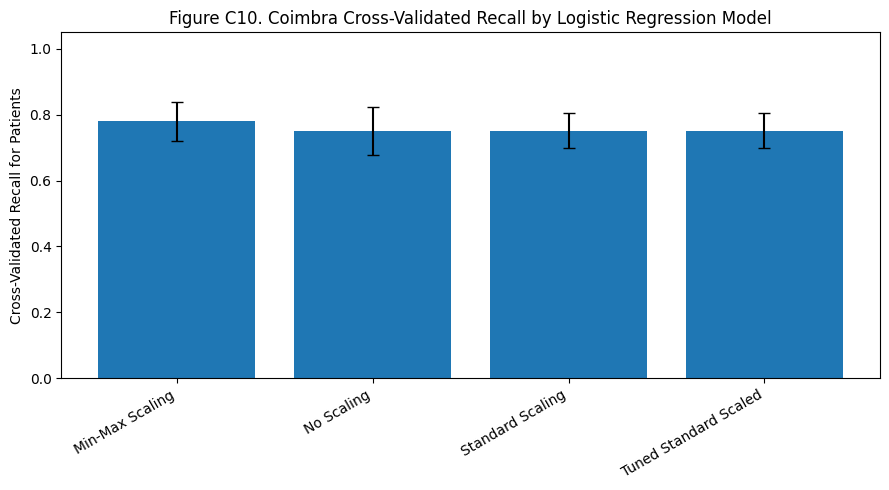

In [48]:
# Figure C10: Coimbra cross-validated recall comparison
plot_df = coimbra_cv_summary_df.sort_values("CV_recall_mean", ascending=False)

plt.figure(figsize=(9, 5))
plt.bar(plot_df["model"], plot_df["CV_recall_mean"], yerr=plot_df["CV_recall_std"], capsize=4)
plt.ylabel("Cross-Validated Recall for Patients")
plt.title("Figure C10. Coimbra Cross-Validated Recall by Logistic Regression Model")
plt.ylim(0, 1.05)
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()


### 2.16 Results summary for the milestone

This cell prints a short summary using the actual results from the Coimbra section. I can use this later when I write Milestone One.

In [49]:
best_cv_model_c = coimbra_cv_summary_df.sort_values("CV_recall_mean", ascending=False).iloc[0]

print("Coimbra Week 4 Summary")
print("Best tuned Coimbra logistic regression parameters:")
print(coimbra_grid.best_params_)

print("\nTuned Coimbra model test results:")
print(f"Accuracy: {coimbra_tuned_results['test_accuracy']:.4f}")
print(f"Precision for patients: {coimbra_tuned_results['test_precision_patient']:.4f}")
print(f"Recall for patients: {coimbra_tuned_results['test_recall_patient']:.4f}")
print(f"F1 for patients: {coimbra_tuned_results['test_f1_patient']:.4f}")
print(f"ROC-AUC: {coimbra_tuned_results['test_roc_auc']:.4f}")

print("\nBest Coimbra model by cross-validated recall:")
print(best_cv_model_c["model"])
print(f"CV Recall: {best_cv_model_c['CV_recall_mean']:.4f} ± {best_cv_model_c['CV_recall_std']:.4f}")
print(f"CV ROC-AUC: {best_cv_model_c['CV_roc_auc_mean']:.4f} ± {best_cv_model_c['CV_roc_auc_std']:.4f}")

print("\nTop 5 Coimbra coefficient features:")
for feature in coimbra_coef_df.head(5)["feature"]:
    print("-", feature)


Coimbra Week 4 Summary
Best tuned Coimbra logistic regression parameters:
{'model__C': np.float64(1.0), 'model__class_weight': None, 'model__penalty': 'l2'}

Tuned Coimbra model test results:
Accuracy: 0.7500
Precision for patients: 0.8182
Recall for patients: 0.6923
F1 for patients: 0.7500
ROC-AUC: 0.7692

Best Coimbra model by cross-validated recall:
Min-Max Scaling
CV Recall: 0.7808 ± 0.0591
CV ROC-AUC: 0.7521 ± 0.1111

Top 5 Coimbra coefficient features:
- Glucose
- Resistin
- Leptin
- BMI
- Insulin


## Part 3 — Comparison and overall conclusions

### 3.1 Comparison: Wisconsin vs. Coimbra

With both datasets analyzed, I can compare logistic regression and feature scaling across two breast cancer datasets.

The **Wisconsin dataset** uses tumor image-based measurements. Since those features describe the tumor directly, I expect logistic regression to perform strongly on Wisconsin.

The **Coimbra dataset** uses clinical and blood-based predictors. These are still meaningful healthcare variables, but they are more indirect than tumor morphology features. Because Coimbra is also much smaller, I expect performance to be less stable and more dependent on cross-validation.

Feature scaling mattered in both datasets because the predictors had very different numeric ranges. In Wisconsin, area-related variables are much larger than smoothness or symmetry. In Coimbra, MCP-1 and insulin are on different scales than age or BMI. Scaling helped make the logistic regression models more appropriate and made the coefficients easier to compare.

### 3.2 Overall Week 4 conclusions

Across the two datasets, I found that logistic regression works naturally for both datasets because both outcomes are binary. For Wisconsin, the model predicts malignant versus benign diagnosis. For Coimbra, the model predicts breast cancer patient versus healthy control.

The main difference is the type of predictors. Wisconsin uses direct tumor measurements, while Coimbra uses clinical and blood-based markers. Because of that, I expect Wisconsin to have stronger and more stable classification performance. Coimbra is still useful because it shows how routine clinical biomarkers may also contain predictive information.

Feature scaling was important in both datasets. It helped because the variables were measured on different scales, and logistic regression with regularization is easier to interpret when features are standardized.

The tuned Coimbra logistic regression model helped me practice hyperparameter tuning using `C`, penalty type, and class weight. I focused on recall because, in a healthcare setting, missing a breast cancer case is more concerning than incorrectly flagging a healthy control.

Overall, Week 4 strengthened my capstone because it gave me a model that is more appropriate for binary classification than the linear probability models from Weeks 1–3. It also helped me compare how logistic regression behaves on image-based tumor data versus clinical biomarker data.

## References

UCI Machine Learning Repository. (n.d.). *Breast Cancer Wisconsin (Diagnostic) dataset*. https://doi.org/10.24432/C5DW2B

Patrício, M., Pereira, J., Crisóstomo, J., Matafome, P., Seiça, R., & Caramelo, F. (2018). *Breast Cancer Coimbra* [Dataset]. UCI Machine Learning Repository. https://doi.org/10.24432/C52P59

Pedregosa, F., Varoquaux, G., Gramfort, A., Michel, V., Thirion, B., Grisel, O., Blondel, M., Prettenhofer, P., Weiss, R., Dubourg, V., Vanderplas, J., Passos, A., Cournapeau, D., Brucher, M., Perrot, M., & Duchesnay, É. (2011). Scikit-learn: Machine learning in Python. *Journal of Machine Learning Research, 12*, 2825–2830.

Scikit-learn developers. (n.d.). *Logistic regression*. https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression

Scikit-learn developers. (n.d.). *Preprocessing data*. https://scikit-learn.org/stable/modules/preprocessing.html